<a href="https://colab.research.google.com/github/Saipradeep456/DATA-SCIENCE-TAINING-/blob/main/Rondom_forest_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Regressor Project

* import the libraies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* link : -'https://raw.githubusercontent.com/sahilrahman12/Price_prediction_of_used_Cars_-Predictive_Analysis-/master/car_data.csv'

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/sahilrahman12/Price_prediction_of_used_Cars_-Predictive_Analysis-/master/car_data.csv')

In [17]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [18]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [20]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [21]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [22]:
df.shape

(4340, 8)

In [23]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [28]:

print("Fuel_type",df.fuel.unique())
print("seller_type",df.seller_type.unique())
print("tramsiion",df.transmission.unique())
print("owner",df.owner.unique())


Fuel_type ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
seller_type ['Individual' 'Dealer' 'Trustmark Dealer']
tramsiion ['Manual' 'Automatic']
owner ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [29]:
df['current_year']=2021

In [30]:
df['no of year'] = df['current_year'] - df['year']

In [32]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,current_year,no of year
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,2021,14
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,2021,14
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,2021,9
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,2021,4
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,2021,7


In [33]:
df.name.unique()

array(['Maruti 800 AC', 'Maruti Wagon R LXI Minor',
       'Hyundai Verna 1.6 SX', ..., 'Mahindra Verito 1.5 D6 BSIII',
       'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
       'Hyundai i20 Magna 1.4 CRDi'], dtype=object)

In [34]:
df.year.unique()

array([2007, 2012, 2017, 2014, 2016, 2015, 2018, 2019, 2013, 2011, 2010,
       2009, 2006, 1996, 2005, 2008, 2004, 1998, 2003, 2002, 2020, 2000,
       1999, 2001, 1995, 1997, 1992])

In [35]:
df.drop(['name','year','current_year'],axis=1,inplace=True)

In [37]:
df.head(13)

,selling_price,km_driven,fuel,seller_type,transmission,owner,no of year
0,60000,70000,Petrol,Individual,Manual,First Owner,14
1,135000,50000,Petrol,Individual,Manual,First Owner,14
2,600000,100000,Diesel,Individual,Manual,First Owner,9
3,250000,46000,Petrol,Individual,Manual,First Owner,4
4,450000,141000,Diesel,Individual,Manual,Second Owner,7
5,140000,125000,Petrol,Individual,Manual,First Owner,14
6,550000,25000,Petrol,Individual,Manual,First Owner,5
7,240000,60000,Petrol,Individual,Manual,Second Owner,7
8,850000,25000,Petrol,Individual,Manual,First Owner,6
9,365000,78000,CNG,Individual,Manual,First Owner,4


In [43]:
df = pd.get_dummies(df)

In [44]:
df.head()

,selling_price,km_driven,no of year,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,14,False,False,False,False,True,False,True,False,False,True,True,False,False,False,False
1,135000,50000,14,False,False,False,False,True,False,True,False,False,True,True,False,False,False,False
2,600000,100000,9,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False
3,250000,46000,4,False,False,False,False,True,False,True,False,False,True,True,False,False,False,False
4,450000,141000,7,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False


In [45]:
df.shape

(4340, 18)

In [47]:
df.drop(['fuel_CNG','seller_type_Dealer','transmission_Automatic'],axis=1,inplace=True)

In [48]:
df.head()

,selling_price,km_driven,no of year,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,14,False,False,False,True,True,False,True,True,False,False,False,False
1,135000,50000,14,False,False,False,True,True,False,True,True,False,False,False,False
2,600000,100000,9,True,False,False,False,True,False,True,True,False,False,False,False
3,250000,46000,4,False,False,False,True,True,False,True,True,False,False,False,False
4,450000,141000,7,True,False,False,False,True,False,True,False,False,True,False,False


In [49]:
df.shape

(4340, 15)

In [50]:
df.corr()

,selling_price,km_driven,no of year,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
selling_price,1.000000,-0.192289,-0.413922,0.282947,-0.005095,-0.042434,-0.269453,-0.236798,0.110176,-0.530205,0.223889,-0.078725,-0.161986,0.048799,-0.111326
km_driven,-0.192289,1.000000,0.419688,0.285396,-0.001372,0.036652,-0.291139,0.182663,-0.089858,0.120226,-0.299731,0.097349,0.195203,-0.083445,0.194713
no of year,-0.413922,0.419688,1.000000,-0.121424,0.025540,0.051266,0.114908,0.173703,-0.100225,0.143800,-0.438897,0.186361,0.292349,-0.095795,0.244308
fuel_Diesel,0.282947,0.285396,-0.121424,1.000000,-0.015063,-0.072422,-0.970934,-0.035314,-0.007911,-0.048098,-0.000878,-0.021054,0.003524,-0.010575,0.009373
fuel_Electric,-0.005095,-0.001372,0.025540,-0.015063,1.000000,-0.001108,-0.014856,-0.026118,-0.002355,-0.044746,-0.020804,-0.002094,0.025960,-0.000952,-0.004166
fuel_LPG,-0.042434,0.036652,0.051266,-0.072422,-0.001108,1.000000,-0.071427,0.035122,-0.011324,0.024764,-0.033379,0.013384,0.030141,-0.004577,0.004836
fuel_Petrol,-0.269453,-0.291139,0.114908,-0.970934,-0.014856,-0.071427,1.000000,0.029845,0.012489,0.039614,0.011296,0.011502,-0.012717,0.012427,-0.008502
seller_type_Individual,-0.236798,0.182663,0.173703,-0.035314,-0.026118,0.035122,0.029845,1.000000,-0.266904,0.214163,-0.252628,0.072322,0.186573,-0.107886,0.140823
seller_type_Trustmark Dealer,0.110176,-0.089858,-0.100225,-0.007911,-0.002355,-0.011324,0.012489,-0.266904,1.000000,-0.042346,0.100430,-0.021395,-0.076764,-0.009729,-0.042578
transmission_Manual,-0.530205,0.120226,0.143800,-0.048098,-0.044746,0.024764,0.039614,0.214163,-0.042346,1.000000,-0.090121,0.035597,0.068068,0.009152,0.030802


<Figure size 2000x2000 with 0 Axes>

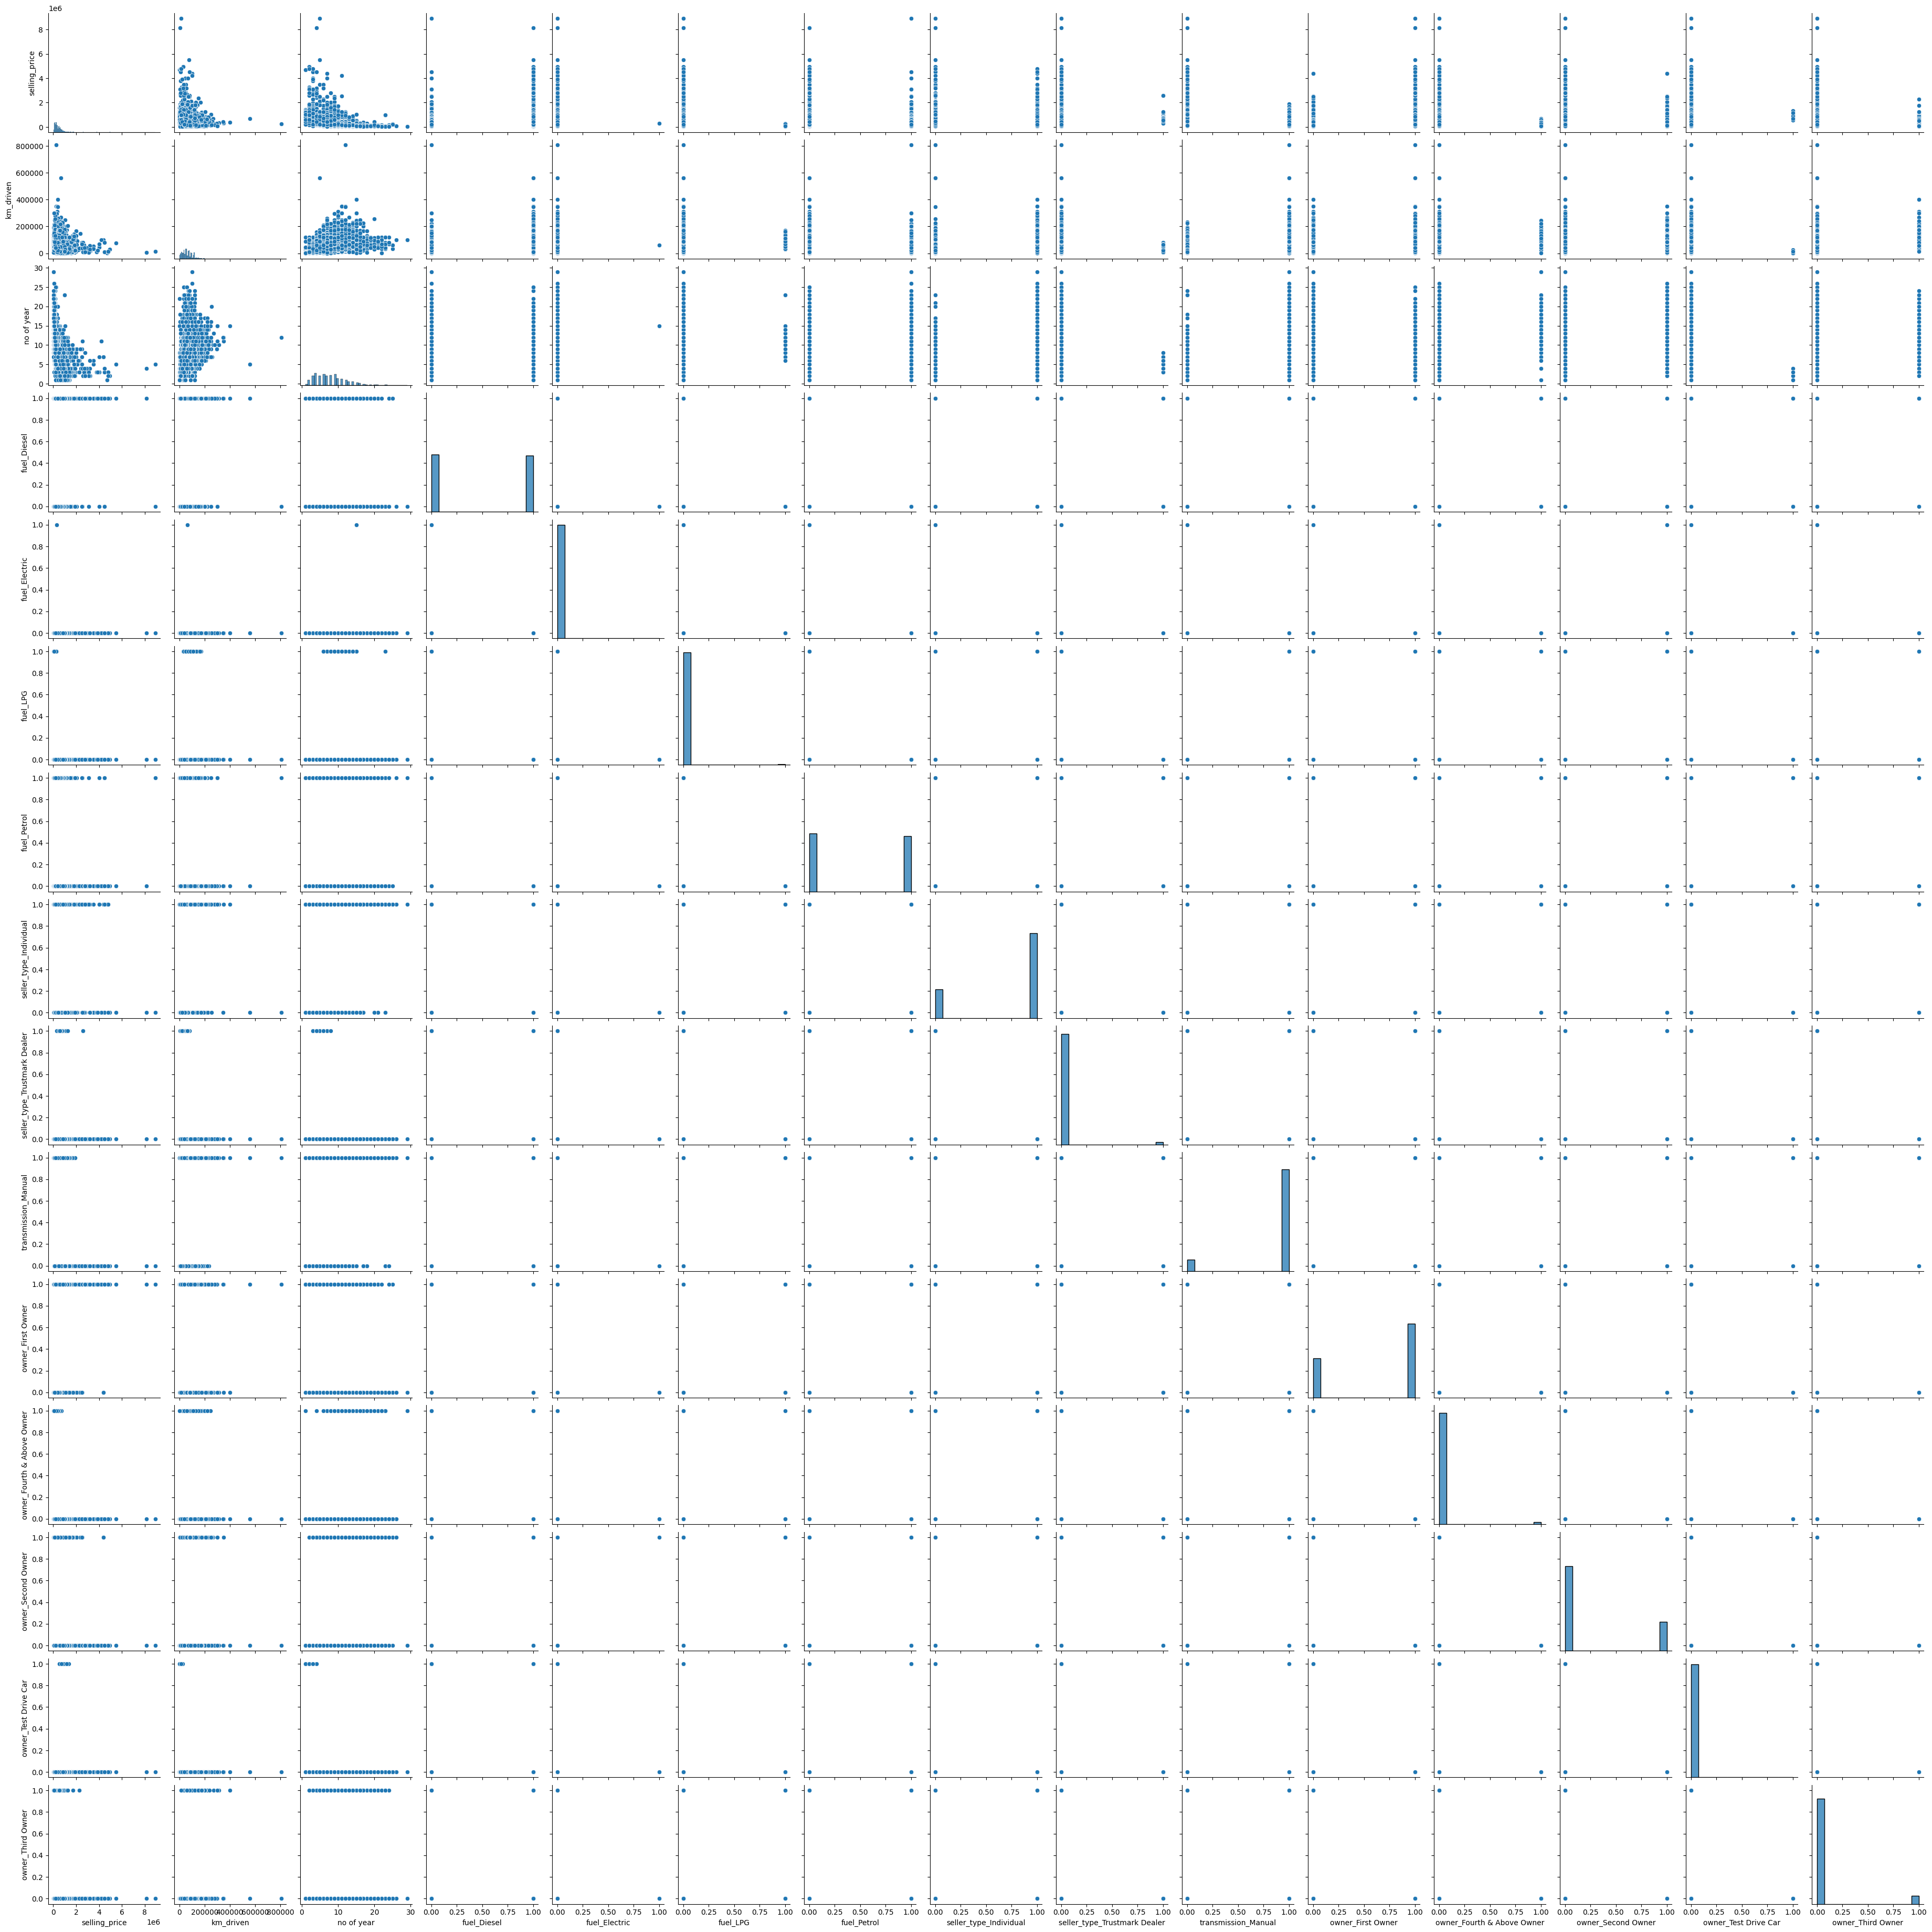

In [60]:
plt.figure(figsize=(20,20))
sns.pairplot(df)

<Axes: >

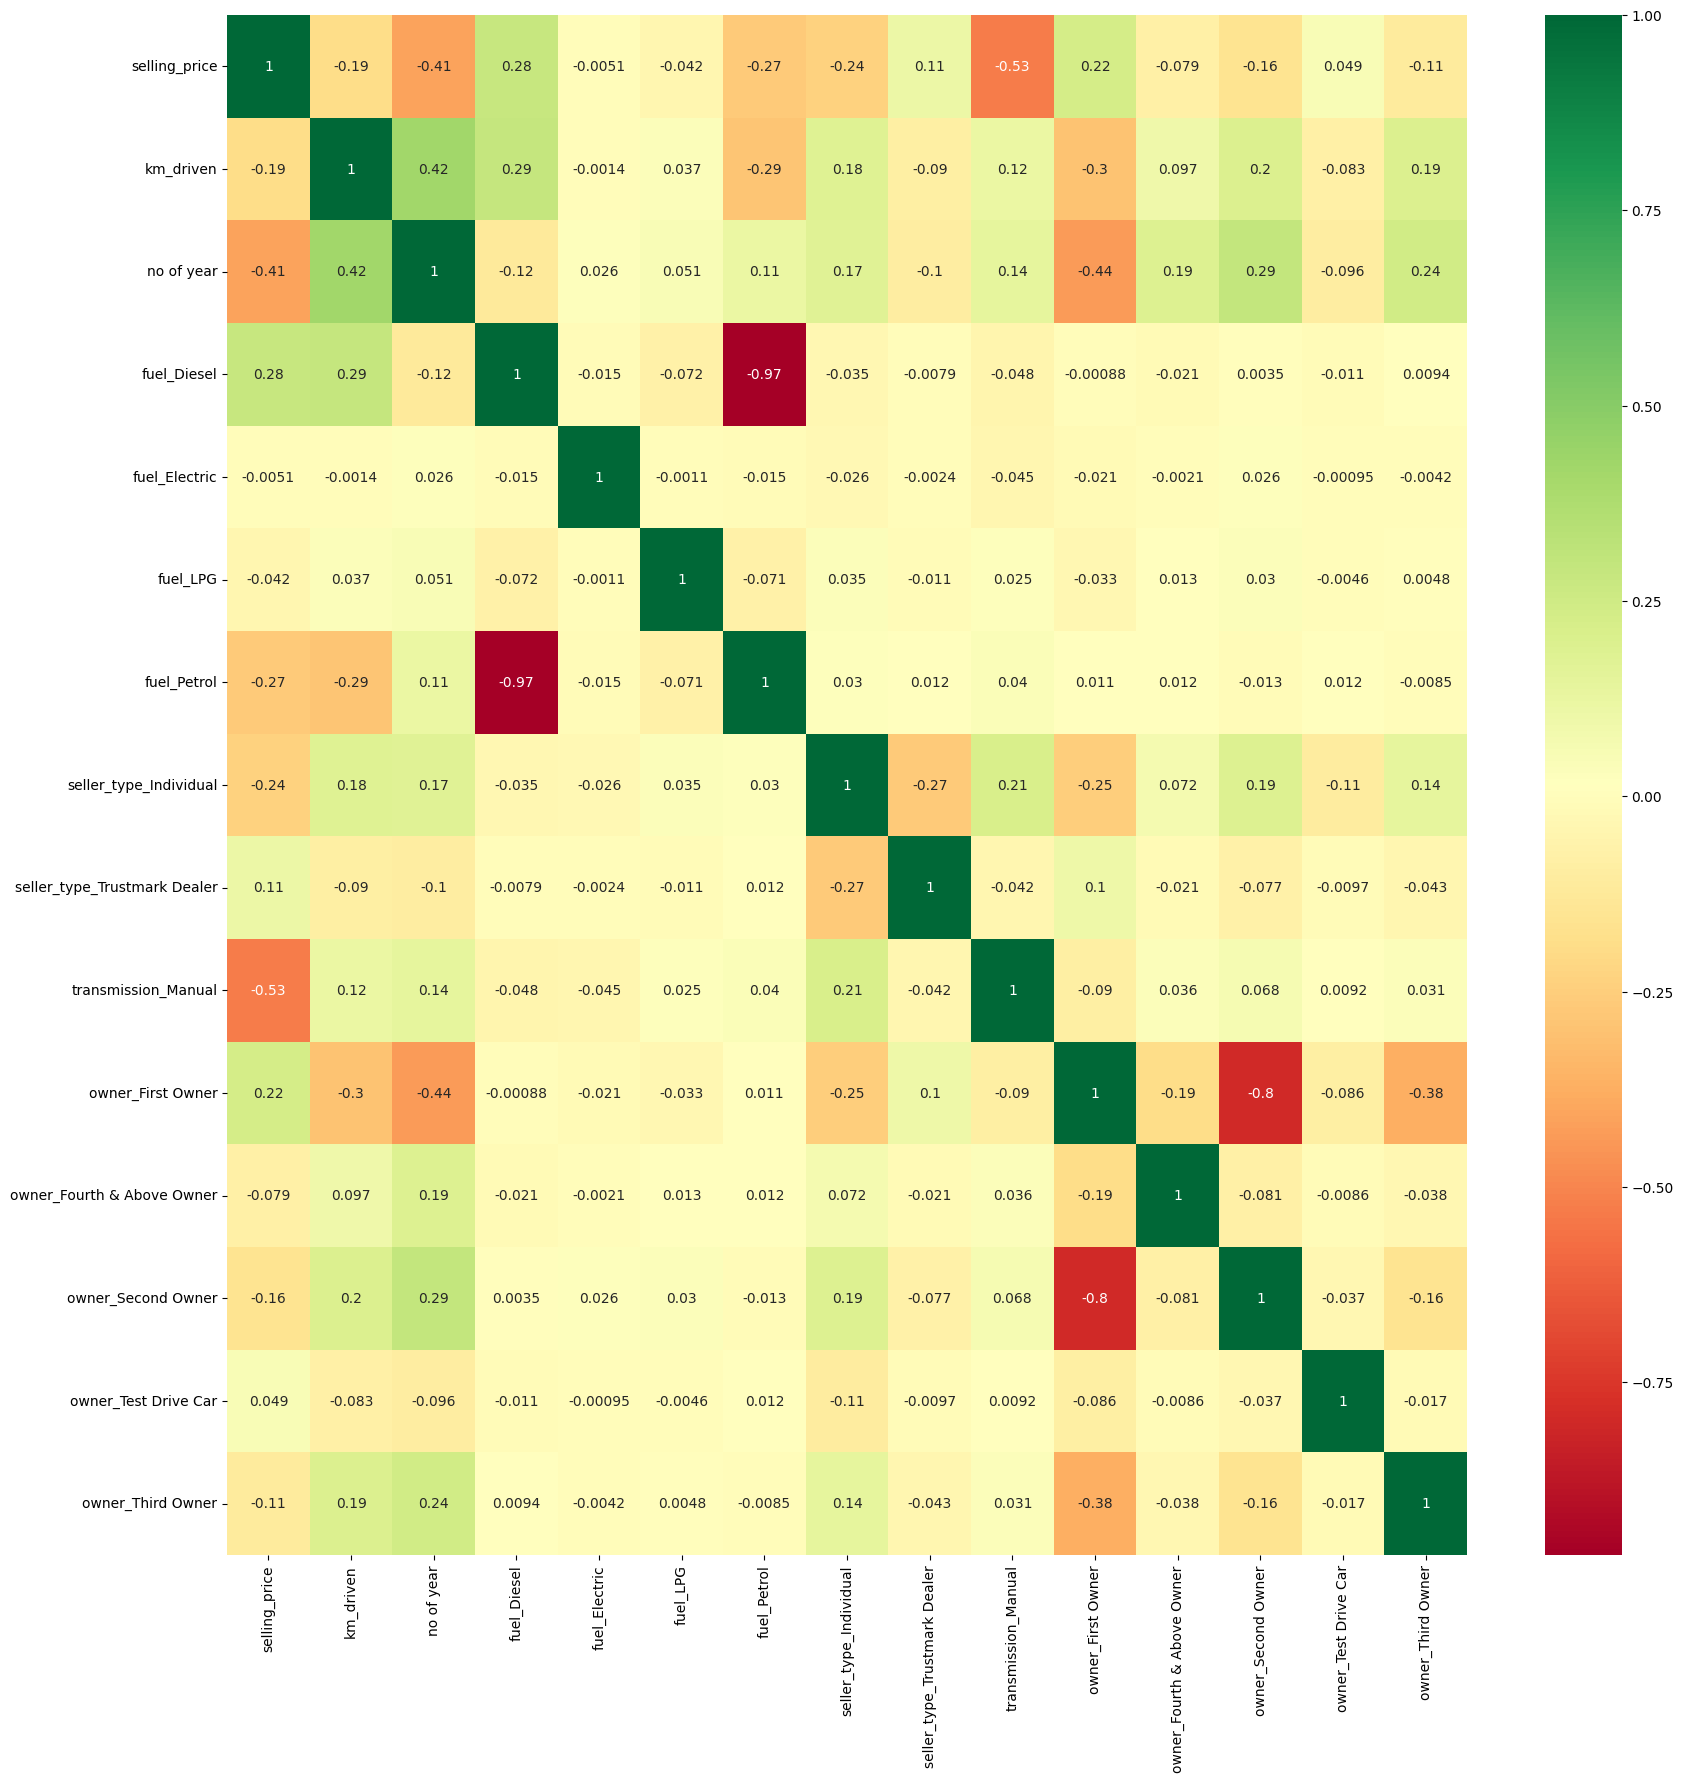

In [59]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn')

In [62]:
df.head(1)

,selling_price,km_driven,no of year,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,14,False,False,False,True,True,False,True,True,False,False,False,False


In [65]:
# x = np.array(df.drop(['selling_price'],axis=1))
x = np.array(df.iloc[:,1:])
y= np.array(df.iloc[:,0])

In [66]:
x

array([[70000, 14, False, ..., False, False, False],
       [50000, 14, False, ..., False, False, False],
       [100000, 9, True, ..., False, False, False],
       ...,
       [83000, 12, False, ..., True, False, False],
       [90000, 5, True, ..., False, False, False],
       [40000, 5, False, ..., False, False, False]], dtype=object)

In [67]:
y

array([ 60000, 135000, 600000, ..., 110000, 865000, 225000])

* Feature selection (feature importance)

In [72]:
from sklearn.ensemble import ExtraTreesRegressor


In [74]:
model = ExtraTreesRegressor() # Create an instance of the ExtraTreesRegressor class
feat_imp = model.fit(x,y)

In [75]:
feat_imp.feature_importances_

array([2.46849583e-01, 2.40436224e-01, 1.30098255e-01, 4.94480442e-05,
       2.47183120e-05, 2.03472012e-04, 4.32366485e-02, 8.17317049e-03,
       2.92828943e-01, 2.48339797e-02, 3.91933947e-04, 8.87547752e-03,
       2.03791459e-03, 1.96023220e-03])

<Axes: >

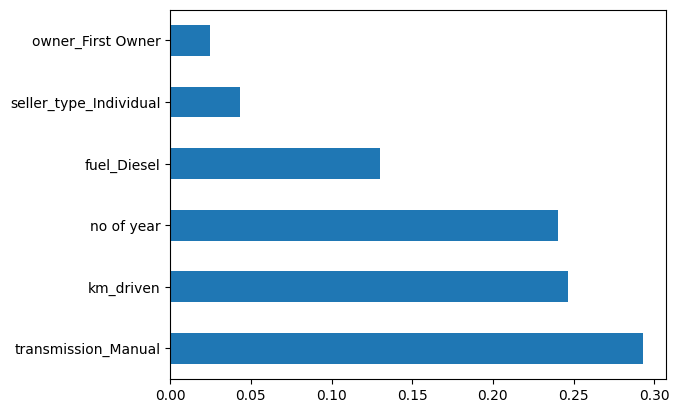

In [82]:
imp = pd.Series(feat_imp.feature_importances_,index=df.columns[1:])
imp.nlargest(6).plot(kind='barh')

* spliting the data

In [84]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [85]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [86]:
x_train

array([[175000, 6, True, ..., False, False, False],
       [170000, 9, True, ..., False, False, False],
       [110000, 15, False, ..., False, False, False],
       ...,
       [22000, 5, False, ..., False, False, False],
       [70000, 6, True, ..., False, False, False],
       [62000, 8, False, ..., True, False, False]], dtype=object)

In [87]:
y_test

array([ 465000, 1580000,  150000, 4950000,  125000,  220000,  450000,
        190000,  740000,  300000,  200000,  775000,  625000,  250000,
        200000,  670000,  400000,  400000,  163000,  630000,   69000,
        450000,  450000,  240000,  355000,  440000,  515000,  600000,
        600000,  220000,  400000,  265000, 1050000, 1200000,  180000,
        180000,   73000,  120000,  225000,  550000,   80000,  495000,
        425000, 2000000,  600000,  170000,   75000,  110000,  725000,
        280000,  140000,  400000,  625000, 1050000,  520000,  285000,
       4950000,  240000,  600000,  300000,  300000,   75000,  368000,
        575000,  486000,  585000,  250000,  250000, 1025000,  520000,
         55000,  200000,  275000,  700000,  350000,  500000,  600000,
        550000,  450000,  190000,  310000,  260000,  620000,  300000,
        175000, 2500000,  625000,  409999, 1200000,  310000, 1295000,
        150000,  390000,  550000,  260000,  320000,  425000,  100000,
        400000,  350

In [88]:
x_test

array([[70070, 9, True, ..., False, False, False],
       [86000, 8, True, ..., False, False, False],
       [120000, 7, False, ..., False, False, True],
       ...,
       [42000, 8, False, ..., False, False, True],
       [60000, 16, False, ..., False, False, True],
       [10000, 3, True, ..., False, False, False]], dtype=object)

* Model selection

In [89]:
Regressor = RandomForestRegressor()

In [90]:
Regressor.fit(x_train,y_train)

RandomForestRegressor()

In [91]:
from  sklearn.model_selection import RandomizedSearchCV

In [93]:
# Define the hyperparameter grid to search
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [94]:
fianl_regressor =  RandomizedSearchCV(estimator=Regressor,param_distributions=random_grid,scoring='neg_mean_squared_error',cv=5,
                                     verbose=2,
                                      random_state=42,n_jobs=1)

* training model

In [95]:
fianl_regressor.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   2.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   2.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   2.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   2.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   2.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   2.9s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   3.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimator

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [96]:
fianl_regressor.best_params_

{'n_estimators': 1100,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 15}

# New Section

In [97]:
y_pred = fianl_regressor.predict(x_test)

In [98]:
y_pred

array([1089375.99291641, 1489545.46300366,  237168.75032935,
       3910761.52971318,  239416.47313489,  178548.49062991,
        817675.64146567,  296777.6579264 , 1316145.02881808,
        452644.59764784,  289851.82743942,  416841.95640576,
        688015.28044034,  539061.63080929,  171001.7195782 ,
        679543.51247858,  463602.870149  ,  259377.71756586,
        114707.26068006,  565967.80117825,   92662.28399259,
        509654.34787285,  406291.60778137,  406731.62167091,
        851769.97075129,  648185.00766543,  628261.84606884,
        501354.96235215,  586264.61536625,  412003.51813451,
        384140.44781359,  485183.97045499,  435134.74214665,
        756614.66321412,  302320.05992423,  448648.49565885,
        336129.25444456,  110624.34570484,  231321.00584521,
        389832.63508162,  189858.22162983,  526500.32567855,
        583155.56009439, 1802553.11604678,  429953.6470555 ,
        269959.01999014,  121123.68547811,  389673.60400466,
        535288.16822551,

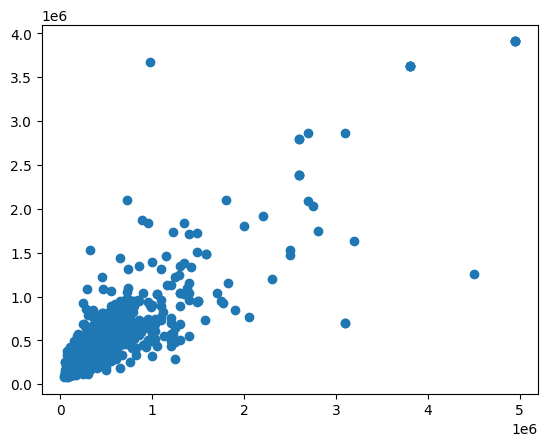

In [99]:
plt.scatter(y_test,y_pred)

In [100]:
finaldf = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})

In [101]:
finaldf

,Actual,Predicted
0,465000,1.089376e+06
1,1580000,1.489545e+06
2,150000,2.371688e+05
3,4950000,3.910762e+06
4,125000,2.394165e+05
...,...,...
863,125000,2.092775e+05
864,300000,3.345969e+05
865,210000,2.070494e+05
866,60000,9.859303e+04


<Axes: >

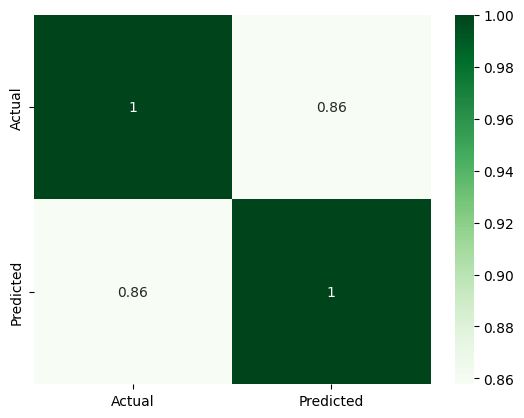

In [103]:
sns.heatmap(finaldf.corr(),annot=True,cmap='Greens')

# performance /Accuracy

In [104]:
from sklearn.metrics import r2_score ,mean_absolute_error,mean_squared_error

In [105]:
r2_score(y_test,y_pred)

0.7343634213060324

In [106]:
mean_squared_error(y_test,y_pred)

98644462987.81914

In [107]:
mean_absolute_error(y_test,y_pred)

171770.3989982835